<a href="https://colab.research.google.com/github/JuanFerMC/TeoriaDelLenguaje-LABS/blob/main/Lab_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 04
---
## Auntomatas de pila

**Integrantes**:
- Juan Fernando Mona Cano | juanf.mona@udea.edu.co
- Ulises Orozco Villegas  | ulises.orozco@udea.edu.co

# Objetivo
---
El objetivo de este proyecto es diseñar e implementar un simulador computacional de un Autómata de Pila Determinista capaz de reconocer el lenguaje formal:
- $L={w^ma^n(i+j)d^nw^{-1} ∣ n,m ≥ 0, w ∈ (b+c)∗}$.

Específicamente, se busca:

  - Demostrar la capacidad de la memoria LIFO (Last-Input, First-Output) para validar simetrías y conteos exactos.

  - Visualizar la transición de estados y la evolución del contenido de la pila en tiempo real.

  - Validar cadenas generadas automáticamente o ingresadas manualmente por el usuario.

# **Cuerpo del Informe**
---
## **Definición del Lenguaje**

El lenguaje propuesto es de tipo Libre de Contexto. Se divide en cinco segmentos críticos que el autómata debe gestionar:

  - **Prefijo $(w)$:** Una cadena de 'b's y 'c's de longitud m. Estos elementos se guardan en la pila para recordar su orden.

  - **Bloque Central de Conteo $(an)$:** Una secuencia de 'a's que se apilan sobre w.

  - **Pivote $((i o j))$:** Un marcador de centro que indica al autómata que debe dejar de "guardar" y empezar a "comparar".

  - **Bloque de Validación $(dn)$:** Por cada 'd', se debe desapilar una 'a'. Esto garantiza que la cantidad de 'd's sea igual a la de 'a's.

  - **Sufijo Espejo $(w^{-1})$:** Al agotar las 'a's, la pila expone nuevamente los caracteres de w. Debido al comportamiento de la pila, estos salen en orden inverso, permitiendo validar la simetría $w^{-1}$.

## **Arquitectura de la Solución**

El programa fue desarrollado en Python utilizando una lógica de estados:

  - **Estado $Q1$​ `(Lectura de w)`:** Identifica caracteres {b,c} y aumenta el contador m.

  - **Estado $Q2$​ `(Lectura de a)`:** Identifica el cambio de carácter y aumenta el contador n.

  - **Estado $Q3​$ `(Transición)`:** Reconoce el pivote. Es el punto de no retorno `(determinismo)`.

  - **Estado $Q4$​ `(Validación de n)`:** Compara la entrada 'd' con el tope de la pila `('a')`.

  - **Estado Q5​ (Validación de m):** Compara el resto de la entrada con el contenido remanente de la pila.

## **Componente Gráfico (Simulación)**

Para la simulación en Google Colab, se implementó una interfaz basada en consola dinámica que utiliza la limpieza de pantalla `(clear_output)` para mostrar:

  - El apuntador de lectura sobre la cadena de entrada.

  - Los contadores dinámicos de n y m.

  - Una representación visual de la pila `(el "stack")` donde se observa físicamente cómo los elementos entran `(Push)` y salen `(Pop)`.

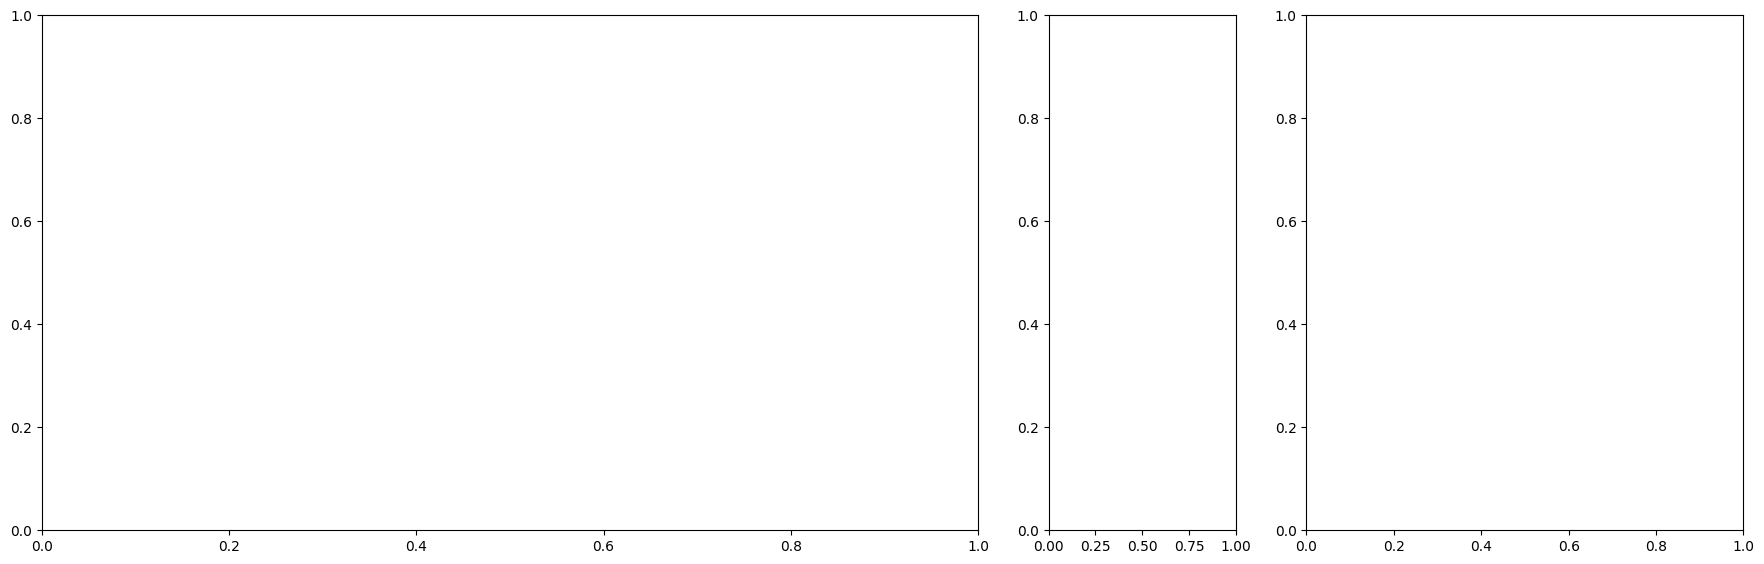

In [ ]:
import time
import random
import ipywidgets as widgets
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, clear_output

ESTADOS = ["Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10","Qf"]

TRANSICIONES = [
    ("Q1",  "Q1",  "b/c→push"),
    ("Q1",  "Q2",  "a→push"),
    ("Q2",  "Q2",  "a→push"),
    ("Q2",  "Q3",  "i→pivote"),
    ("Q3",  "Q4",  "d→pop a"),
    ("Q4",  "Q4",  "d→pop a"),
    ("Q4",  "Q5",  "b/c→pop"),
    ("Q5",  "Q5",  "b/c→pop"),
    ("Q5",  "Q6",  "b/c→push"),
    ("Q6",  "Q6",  "b/c→push"),
    ("Q6",  "Q7",  "a→push"),
    ("Q7",  "Q7",  "a→push"),
    ("Q7",  "Q8",  "j→pivote"),
    ("Q8",  "Q9",  "d→pop a"),
    ("Q9",  "Q9",  "d→pop a"),
    ("Q9",  "Q10", "b/c→pop"),
    ("Q10", "Q10", "b/c→pop"),
    ("Q10", "Qf",  "pila vacía"),
]

def simular(cadena):
    pasos = []
    pila, idx, m1, n1, m2, n2 = [], 0, 0, 0, 0, 0

    def snap(estado, msg, **extra):
        pasos.append({
            "estado": estado,
            "idx":    idx,
            "pila":   list(pila),
            "msg":    msg,
            "m1": m1, "n1": n1,
            "m2": m2, "n2": n2,
            **extra
        })

    try:
        while idx < len(cadena) and cadena[idx] in ('b','c'):
            pila.append(cadena[idx]); m1 += 1
            snap("Q1", f"Bloque 1 | Leyendo '{cadena[idx]}' → apilado")
            idx += 1

        while idx < len(cadena) and cadena[idx] == 'a':
            pila.append('a'); n1 += 1
            snap("Q2", "Bloque 1 | Leyendo 'a' → apilado")
            idx += 1

        if idx < len(cadena) and cadena[idx] == 'i':
            snap("Q3", "Bloque 1 | Pivote 'i' detectado")
            idx += 1
        else:
            snap("Q3",
                 f"ERROR: se esperaba pivote 'i', llegó "
                 f"'{cadena[idx] if idx < len(cadena) else 'EOF'}'",
                 error=True)
            return pasos

        vn1 = 0
        while idx < len(cadena) and cadena[idx] == 'd':
            if pila and pila[-1] == 'a':
                pila.pop(); vn1 += 1
                snap("Q4", "Bloque 1 | 'd' valida 'a' → desapilado")
                idx += 1
            else:
                break

        if vn1 != n1:
            snap("Q4",
                 f"ERROR bloque 1: {n1} 'a' apiladas vs {vn1} 'd' leídas",
                 error=True)
            return pasos

        while idx < len(cadena) and cadena[idx] in ('b','c'):
            if not pila:
                break
            top = pila[-1]
            if cadena[idx] == top:
                pila.pop()
                snap("Q5", f"Bloque 1 | Coincidencia '{cadena[idx]}' con '{top}'")
                idx += 1
            else:
                snap("Q5",
                     f"ERROR bloque 1: esperaba '{top}', llegó '{cadena[idx]}'",
                     error=True)
                return pasos

        if pila:
            snap("Q5",
                 f"ERROR: pila no vacía al terminar bloque 1 "
                 f"(quedan {len(pila)} elementos)",
                 error=True)
            return pasos


        while idx < len(cadena) and cadena[idx] in ('b','c'):
            pila.append(cadena[idx]); m2 += 1
            snap("Q6", f"Bloque 2 | Leyendo '{cadena[idx]}' → apilado")
            idx += 1

        while idx < len(cadena) and cadena[idx] == 'a':
            pila.append('a'); n2 += 1
            snap("Q7", "Bloque 2 | Leyendo 'a' → apilado")
            idx += 1

        if idx < len(cadena) and cadena[idx] == 'j':
            snap("Q8", "Bloque 2 | Pivote 'j' detectado")
            idx += 1
        else:
            snap("Q8",
                 f"ERROR: se esperaba pivote 'j', llegó "
                 f"'{cadena[idx] if idx < len(cadena) else 'EOF'}'",
                 error=True)
            return pasos

        vn2 = 0
        while idx < len(cadena) and cadena[idx] == 'd':
            if pila and pila[-1] == 'a':
                pila.pop(); vn2 += 1
                snap("Q9", "Bloque 2 | 'd' valida 'a' → desapilado")
                idx += 1
            else:
                break

        if vn2 != n2:
            snap("Q9",
                 f"ERROR bloque 2: {n2} 'a' apiladas vs {vn2} 'd' leídas",
                 error=True)
            return pasos

        while idx < len(cadena):
            if not pila:
                snap("Q10",
                     "ERROR bloque 2: pila vacía, cadena no terminó",
                     error=True)
                return pasos
            top = pila[-1]
            if cadena[idx] == top:
                pila.pop()
                snap("Q10", f"Bloque 2 | Coincidencia '{cadena[idx]}' con '{top}'")
                idx += 1
            else:
                snap("Q10",
                     f"ERROR bloque 2: esperaba '{top}', llegó '{cadena[idx]}'",
                     error=True)
                return pasos

        if not pila and idx == len(cadena):
            snap("Qf", "Cadena ACEPTADA — ambos bloques validados", accept=True)
        else:
            snap("Q10",
                 "Cadena RECHAZADA — pila no vacía o cadena incompleta",
                 error=True)

    except Exception as e:
        pasos.append({"estado": "ERR", "idx": idx, "pila": list(pila),
                      "msg": str(e), "m1": m1, "n1": n1,
                      "m2": m2, "n2": n2, "error": True})
    return pasos



POSICIONES = {
    "Q1":  (0,  1), "Q2":  (2,  1), "Q3":  (4,  1),
    "Q4":  (6,  1), "Q5":  (8,  1),
    "Q6":  (0, -1), "Q7":  (2, -1), "Q8":  (4, -1),
    "Q9":  (6, -1), "Q10": (8, -1),
    "Qf":  (10, 0),
}
COLORES_ESTADO = {
    "Q1":  "#CECBF6", "Q2":  "#B5D4F4", "Q3":  "#FAC775",
    "Q4":  "#9FE1CB", "Q5":  "#F5C4B3",
    "Q6":  "#CECBF6", "Q7":  "#B5D4F4", "Q8":  "#FAC775",
    "Q9":  "#9FE1CB", "Q10": "#F5C4B3",
    "Qf":  "#C0DD97",
}
COLOR_ACTIVO = "#534AB7"
COLOR_ERROR  = "#D85A30"
COLOR_ACCEPT = "#1D9E75"

BLOQUE_LABELS = {
    "Q1": "B1", "Q2": "B1", "Q3": "B1", "Q4": "B1", "Q5": "B1",
    "Q6": "B2", "Q7": "B2", "Q8": "B2", "Q9": "B2", "Q10": "B2",
}


def dibujar_pila(ax, pila, y_top=0.95, y_bot=0.02):
    ax.clear()
    ax.set_facecolor("#f8f8f8")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.99, "Pila", ha="center", va="top",
            fontsize=9, fontweight="bold", color="#444444")

    if not pila:
        ax.text(0.5, 0.50, "(vacía)", ha="center", va="center",
                fontsize=9, color="#999999")
        return

    n         = len(pila)
    espacio   = y_top - y_bot
    MAX_CELDAS = int(espacio / 0.06)

    if n <= MAX_CELDAS:
        mostrar     = list(reversed(pila))
        cell_h      = espacio / n
        hay_recorte = False
    else:
        mostrar     = list(reversed(pila))[:MAX_CELDAS]
        cell_h      = espacio / MAX_CELDAS
        hay_recorte = True
        ocultos     = n - MAX_CELDAS

    for k, elem in enumerate(mostrar):
        y = y_top - k * cell_h
        rect = mpatches.FancyBboxPatch(
            (0.15, y - cell_h + 0.004), 0.70, cell_h - 0.008,
            boxstyle="round,pad=0.008",
            facecolor="#185FA5", edgecolor="none"
        )
        ax.add_patch(rect)
        fs = max(6, min(10, cell_h * 55))
        ax.text(0.50, y - cell_h / 2, elem,
                ha="center", va="center",
                fontsize=fs, color="white", fontweight="bold")

    if hay_recorte:
        ax.text(0.50, y_bot - 0.01, f"…y {ocultos} más",
                ha="center", va="top", fontsize=7, color="#666666")


def dibujar_automata(estado_activo=None, es_error=False, es_accept=False,
                     cadena="", idx=0, pila=None, msg="",
                     m1=0, n1=0, m2=0, n2=0,
                     ax_grafo=None, ax_pila=None, ax_info=None):

    G = nx.DiGraph()
    G.add_nodes_from(ESTADOS)
    for src, dst, _ in TRANSICIONES:
        G.add_edge(src, dst)

    colores_nodos, borde_nodos, tamaños = [], [], []
    for e in ESTADOS:
        if e == estado_activo:
            colores_nodos.append(COLOR_ERROR if es_error
                                 else COLOR_ACCEPT if es_accept
                                 else COLOR_ACTIVO)
            borde_nodos.append(COLOR_ACTIVO)
            tamaños.append(3000)
        else:
            colores_nodos.append(COLORES_ESTADO.get(e, "#f0f0f0"))
            borde_nodos.append("#aaaaaa")
            tamaños.append(2000)

    ax_grafo.clear()
    ax_grafo.set_facecolor("#fafafa")

    for (x0, y0, w, h, label, color) in [
        (-0.8,  0.35, 9.6, 1.3, "Bloque 1  (···i···)", "#EEEDFE"),
        (-0.8, -1.65, 9.6, 1.3, "Bloque 2  (···j···)", "#E1F5EE"),
    ]:
        rect = mpatches.FancyBboxPatch(
            (x0, y0), w, h,
            boxstyle="round,pad=0.1",
            facecolor=color, edgecolor="#cccccc",
            linewidth=0.8, zorder=0,
            transform=ax_grafo.transData
        )
        ax_grafo.add_patch(rect)
        ax_grafo.text(x0 + 0.15, y0 + h - 0.12, label,
                      fontsize=8, color="#666666", va="top")

    nx.draw_networkx_nodes(G, POSICIONES, ax=ax_grafo,
                           node_color=colores_nodos, node_size=tamaños,
                           edgecolors=borde_nodos,
                           linewidths=[2.5 if e == estado_activo else 1
                                       for e in ESTADOS])
    nx.draw_networkx_labels(G, POSICIONES, ax=ax_grafo,
                            font_size=9, font_weight="bold",
                            font_color="white")
    nx.draw_networkx_edges(G, POSICIONES, ax=ax_grafo,
                           arrows=True, arrowsize=16,
                           edge_color="#888888",
                           connectionstyle="arc3,rad=0.18",
                           min_source_margin=20, min_target_margin=20)
    etiquetas = {(s, d): lbl for s, d, lbl in TRANSICIONES}
    nx.draw_networkx_edge_labels(G, POSICIONES, etiquetas,
                                 ax=ax_grafo, font_size=6.5,
                                 font_color="#555555",
                                 bbox=dict(boxstyle="round,pad=0.12",
                                           fc="white", alpha=0.75, ec="none"))
    ax_grafo.set_title(
        "Autómata de Pila — L = { w₁ aⁿ i dⁿ w₁⁻¹  w₂ aⁿ j dⁿ w₂⁻¹ }",
        fontsize=10, pad=8)
    ax_grafo.axis("off")

    dibujar_pila(ax_pila, pila or [])

    ax_info.clear()
    ax_info.set_facecolor("#f8f8f8")
    ax_info.axis("off")
    ax_info.set_xlim(0, 1)
    ax_info.set_ylim(0, 1)

    if cadena:
        n_ch    = len(cadena)
        cell_w  = min(0.055, 0.96 / n_ch)
        start_x = (1 - n_ch * cell_w) / 2
        for i, ch in enumerate(cadena):
            color = (COLOR_ACTIVO if i == idx
                     else "#cccccc" if i < idx
                     else "white")
            rect = mpatches.FancyBboxPatch(
                (start_x + i * cell_w, 0.74),
                cell_w - 0.004, 0.18,
                boxstyle="round,pad=0.01",
                facecolor=color, edgecolor="#aaaaaa", linewidth=0.5
            )
            ax_info.add_patch(rect)
            fs = max(6, min(9, cell_w * 110))
            ax_info.text(start_x + i * cell_w + cell_w / 2, 0.83, ch,
                         ha="center", va="center", fontsize=fs,
                         color="white" if i <= idx else "#333333",
                         fontweight="bold" if i == idx else "normal")

    ax_info.text(0.03, 0.68,
                 f"Estado: {estado_activo or '—'}   |   "
                 f"Índice: {idx}/{len(cadena)}",
                 fontsize=9, va="top", color="#444444")
    ax_info.text(0.03, 0.60,
                 f"Bloque 1 → m₁={m1}  n₁={n1}     "
                 f"Bloque 2 → m₂={m2}  n₂={n2}",
                 fontsize=8, va="top", color="#666666")

    color_msg = (COLOR_ERROR if es_error
                 else COLOR_ACCEPT if es_accept
                 else "#333333")
    ax_info.text(0.03, 0.50, f"ℹ  {msg}",
                 fontsize=9, va="top", color=color_msg,
                 fontweight="bold" if (es_error or es_accept) else "normal",
                 wrap=True)

    ax_info.text(0.03, 0.38,
                 f"Elementos en pila: {len(pila or [])}",
                 fontsize=8, va="top", color="#888888")

def crear_interfaz():
    txt_cadena = widgets.Text(
        value="bccbaaiddbccbbccbaajddbccb",
        description="Cadena:",
        layout=widgets.Layout(width="400px"),
        style={"description_width": "70px"}
    )

    txt_m1 = widgets.BoundedIntText(value=5, min=0, max=20, description="m₁:",
                                    layout=widgets.Layout(width="120px"),
                                    style={"description_width": "28px"})
    txt_n1 = widgets.BoundedIntText(value=2, min=0, max=20, description="n₁:",
                                    layout=widgets.Layout(width="120px"),
                                    style={"description_width": "28px"})
    dd_w1  = widgets.Dropdown(
        options=[("Solo 'b'", 'b'), ("Solo 'c'", 'c'), ("Mezcla b/c", 'm')],
        value='m', description="w₁:",
        layout=widgets.Layout(width="190px"),
        style={"description_width": "28px"}
    )

    txt_m2 = widgets.BoundedIntText(value=5, min=0, max=20, description="m₂:",
                                    layout=widgets.Layout(width="120px"),
                                    style={"description_width": "28px"})
    txt_n2 = widgets.BoundedIntText(value=2, min=0, max=20, description="n₂:",
                                    layout=widgets.Layout(width="120px"),
                                    style={"description_width": "28px"})
    dd_w2  = widgets.Dropdown(
        options=[("Solo 'b'", 'b'), ("Solo 'c'", 'c'), ("Mezcla b/c", 'm')],
        value='m', description="w₂:",
        layout=widgets.Layout(width="190px"),
        style={"description_width": "28px"}
    )

    vel_slider = widgets.FloatSlider(
        value=0.4, min=0.1, max=2.0, step=0.1,
        description="Velocidad (s):",
        layout=widgets.Layout(width="380px"),
        style={"description_width": "110px"}
    )
    btn_run   = widgets.Button(description="▶ Ejecutar",  button_style="primary",
                               layout=widgets.Layout(width="120px"))
    btn_gen   = widgets.Button(description="⚙ Generar",   button_style="info",
                               layout=widgets.Layout(width="120px"))
    btn_reset = widgets.Button(description="↺ Reiniciar",
                               layout=widgets.Layout(width="120px"))
    out = widgets.Output()

    ui = widgets.VBox([
        widgets.HTML(
            "<h3 style='margin:0 0 6px'>🤖 Simulador de Autómata de Pila — dos bloques</h3>"
            "<p style='margin:0 0 8px;color:#666;font-size:12px'>"
            "L = { w₁ aⁿ <b>i</b> dⁿ w₁⁻¹ · w₂ aⁿ <b>j</b> dⁿ w₂⁻¹ }</p>"
        ),
        widgets.HBox([txt_cadena, btn_run, btn_reset]),
        widgets.HTML("<span style='font-size:11px;color:#888'>Generador — Bloque 1:</span>"),
        widgets.HBox([txt_m1, txt_n1, dd_w1]),
        widgets.HTML("<span style='font-size:11px;color:#888'>Generador — Bloque 2:</span>"),
        widgets.HBox([txt_m2, txt_n2, dd_w2, btn_gen]),
        widgets.HBox([vel_slider]),
        out
    ])
    display(ui)

    def _hacer_w(op, m):
        if   op == 'b': return 'b' * m
        elif op == 'c': return 'c' * m
        else:           return ''.join(random.choice('bc') for _ in range(m))

    def generar(_):
        w1 = _hacer_w(dd_w1.value, txt_m1.value)
        w2 = _hacer_w(dd_w2.value, txt_m2.value)
        bloque1 = w1 + 'a' * txt_n1.value + 'i' + 'd' * txt_n1.value + w1[::-1]
        bloque2 = w2 + 'a' * txt_n2.value + 'j' + 'd' * txt_n2.value + w2[::-1]
        txt_cadena.value = bloque1 + bloque2

    def ejecutar(_):
        cadena = txt_cadena.value.strip()
        if not cadena:
            return
        pasos = simular(cadena)
        vel   = vel_slider.value

        fig, (ax_g, ax_p, ax_i) = plt.subplots(
            1, 3, figsize=(18, 6),
            gridspec_kw={"width_ratios": [3, 0.6, 1.4]}
        )
        plt.tight_layout(pad=2)

        with out:
            for paso in pasos:
                clear_output(wait=True)
                dibujar_automata(
                    estado_activo = paso["estado"],
                    es_error      = paso.get("error",  False),
                    es_accept     = paso.get("accept", False),
                    cadena        = cadena,
                    idx           = paso["idx"],
                    pila          = paso["pila"],
                    msg           = paso["msg"],
                    m1=paso["m1"], n1=paso["n1"],
                    m2=paso["m2"], n2=paso["n2"],
                    ax_grafo      = ax_g,
                    ax_pila       = ax_p,
                    ax_info       = ax_i,
                )
                display(fig)
                time.sleep(vel)
            plt.close(fig)

    def reiniciar(_):
        with out:
            clear_output()

    btn_gen.on_click(generar)
    btn_run.on_click(ejecutar)
    btn_reset.on_click(reiniciar)

# Ejecutar
crear_interfaz()

# Conclusiones:
- Se comprobó que el autómata de pila es la herramienta mínima necesaria para este lenguaje. Un autómata finito `(sin pila)` no podría reconocerlo ya que no tendría forma de "recordar" cuántas 'a's pasaron ni en qué orden exacto vinieron las 'b's y 'c's.

- El lenguaje es determinista gracias a la presencia del pivote `(i,j)`. Sin este marcador, el autómata tendría dificultades para saber cuándo termina la fase de apilamiento y empieza la de comparación si w pudiera contener caracteres similares a los de los otros bloques.

- La propiedad de la pila de devolver los elementos en orden inverso es lo que facilita la validación de $w^{-1}$ de forma natural, sin necesidad de recorrer la cadena de entrada varias veces.

- La implementación permite tanto el aprendizaje guiado `(generación automática)` como el modo de prueba de errores `(entrada manual)`, lo que lo convierte en una herramienta pedagógica efectiva para la teoría de la computación.